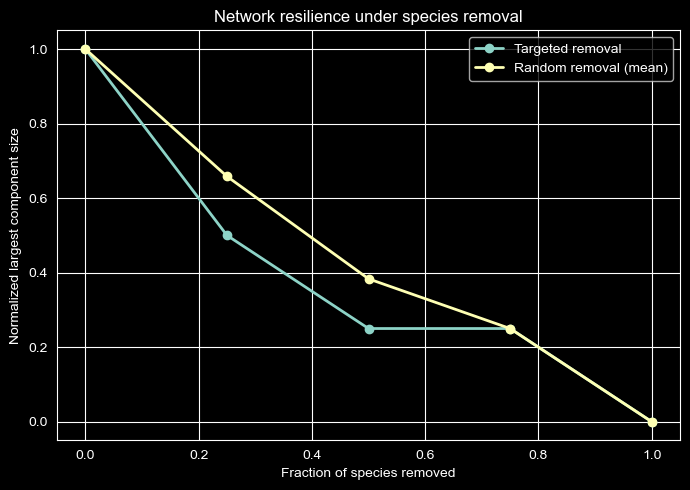

In [2]:
# =========================
# Jupyter setup (IMPORTANT)
# =========================
%matplotlib inline

# =========================
# Imports
# =========================
import matplotlib.pyplot as plt
import numpy as np

from src.data.load_synthetic import load_synthetic_ecosystem
from src.network.build_layers import build_ecological_layer
from src.simulation.removal_strategies import (
    random_removal_order,
    targeted_removal_order
)
from src.metrics.robustness import robustness_curve

# Load synthetic ecosystem
species, edges = load_synthetic_ecosystem(
    "data/raw/synthetic_ecosystem_v1.json"
)

print("Species:", species)
print("Edges:", edges)

# Build ecological network
G = build_ecological_layer(species, edges)

# Targeted removal experiment
order_targeted = targeted_removal_order(G)
f_t, lcc_t = robustness_curve(G, order_targeted)

# Random removal experiment
runs = 30
lcc_random_runs = []

for i in range(runs):
    order_random = random_removal_order(G, seed=i)
    f_r, lcc_r = robustness_curve(G, order_random)
    lcc_random_runs.append(lcc_r)

lcc_random_mean = np.mean(lcc_random_runs, axis=0)

# Print numerical results
print("\n--- Targeted removal ---")
for f, l in zip(f_t, lcc_t):
    print(f"Removed {f:.2f} → LCC {l:.2f}")

print("\n--- Random removal (mean over runs) ---")
for f, l in zip(f_r, lcc_random_mean):
    print(f"Removed {f:.2f} → LCC {l:.2f}")

# Plot resilience curves
plt.figure(figsize=(7, 5))

plt.plot(
    f_t, lcc_t,
    marker="o",
    linewidth=2,
    label="Targeted removal"
)

plt.plot(
    f_r, lcc_random_mean,
    marker="o",
    linewidth=2,
    label="Random removal (mean)"
)

plt.xlabel("Fraction of species removed")
plt.ylabel("Normalized largest component size")
plt.title("Network resilience under species removal")
plt.legend()
plt.grid(True)

plt.tight_layout()
plt.show()
